<a href="https://colab.research.google.com/github/Raju-24-25/Deep-Learning-Handsons/blob/main/Batch_Gradient_Descent%2C_Mini_Batch_Gradient_Descent%2C_Stochestic_Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### GRADIENT DESCENT ALGORITHM DEMONSTRATION

Importing Necessery Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 1. Data Generation and Setup
# -------------------------------

`Simple Linear Regression if it is a 2D` -- Simply one input and one output

In [ ]:
def generate_data (n_samples = 100, noise = 0.1, seed = 42):
  '''
  Generate random Sample (synthetic) Linear Data
  '''
  np.random.seed(seed) # to ensure the reproducibility of the same random data --> to fix the random numbers generated
  X = 2*np.random.randn(n_samples, 1) #generates random numbers from standard normal distribution
  y = 4 + 3*X + noise * np.random.randn(n_samples,1) # creates a random distribution around a line having some noise added to it

  return X, y

In [ ]:
### Let us generate a sample data
X, y = generate_data(n_samples=100, noise=2)

In [ ]:
print("Shape for X, y:", X.shape, y.shape)

Shape for X, y: (100, 1) (100, 1)


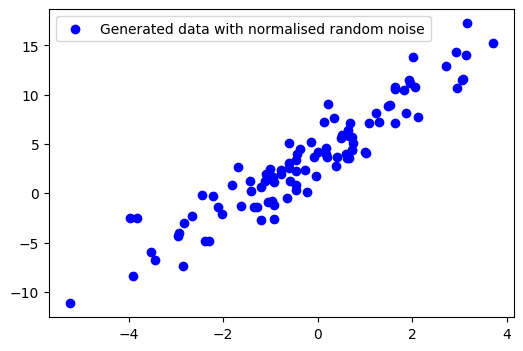

In [ ]:
### Let us plot the generated data distribution
plt.figure(figsize=(6,4))
plt.scatter(X, y, color = 'blue', label = 'Generated data with normalised random noise')
plt.legend()
plt.show()

# Adding a `Unit Bias` term to X

In [ ]:
# Numbers of rows in the data
m = len(y)
print('Number of Rows : ', m)

Number of Rows :  100


In [ ]:
# Let us add the Unit Bias term
X_b = np.c_[np.ones((m,1)), X] ### adding a constant column having entries 1

In [ ]:
X[:10]

array([[ 0.99342831],
       [-0.2765286 ],
       [ 1.29537708],
       [ 3.04605971],
       [-0.46830675],
       [-0.46827391],
       [ 3.15842563],
       [ 1.53486946],
       [-0.93894877],
       [ 1.08512009]])

In [ ]:
X_b[:10]

array([[ 1.        ,  0.99342831],
       [ 1.        , -0.2765286 ],
       [ 1.        ,  1.29537708],
       [ 1.        ,  3.04605971],
       [ 1.        , -0.46830675],
       [ 1.        , -0.46827391],
       [ 1.        ,  3.15842563],
       [ 1.        ,  1.53486946],
       [ 1.        , -0.93894877],
       [ 1.        ,  1.08512009]])

# Define the `Cost Function`

- For Linear Regression example, we are going to use `Mean Squared Error (MSE)`

In [ ]:
def compute_cost (X, y, theta):
  '''
  Compute the mean squared error cost function
  '''
  m = len(y)
  return np.sum((X.dot(theta) - y)**2)/(2*m)

## Writing `Batch Gradient Function`

In [ ]:
def bgd (X, y, theta, learning_rate = 0.01, epochs = 100):
  m = len( y ) #no. of rows/training examples
  ### Empty arrays to track cost and theta history
  cost_history = np.zeros(epochs) # 1D array to store the cost after each epoch
  theta_history = np.zeros((epochs, theta.shape[0])) # 2D array to store the parameter values

  for epoch in range(epochs):
    # Compute the Gradient
    gradients = (1/m)*(X.T.dot(X.dot(theta) - y))

    # Update the parameters
    theta = theta - (learning_rate * gradients)

    # Compute the Cost
    cost = compute_cost(X, y, theta)

    # Store History
    cost_history[epoch] = cost
    theta_history[epoch, : ] = theta.T

  return theta, cost_history, theta_history

# Run the `BGD` Algorithm



In [ ]:
### Initialize the theta values - weight & bias randomly
np.random.seed(30)
theta = np.random.randn(2,1)
print(theta)

[[-1.26405266]
 [ 1.52790535]]


In [ ]:
theta_bgd, cost_history_bgd, theta_history_bgd = bgd(X_b, y, theta, learning_rate=0.1, epochs=100)

In [ ]:
cost_history_bgd

array([13.84405091, 11.39069705,  9.50574584,  8.02181568,  6.83676914,
        5.88267047,  5.11100354,  4.48530827,  3.97726577,  3.56443778,
        3.22883908,  2.95595942,  2.7340495 ,  2.55357654,  2.40679752,
        2.28741939,  2.19032581,  2.11135641,  2.04712777,  1.99488822,
        1.95239981,  1.91784235,  1.88973543,  1.86687497,  1.84828168,
        1.83315902,  1.82085917,  1.81085523,  1.80271863,  1.79610082,
        1.79071829,  1.78634047,  1.78277982,  1.7798838 ,  1.77752836,
        1.77561258,  1.77405441,  1.77278708,  1.77175632,  1.77091796,
        1.77023609,  1.7696815 ,  1.76923042,  1.76886355,  1.76856516,
        1.76832246,  1.76812507,  1.76796452,  1.76783394,  1.76772773,
        1.76764135,  1.7675711 ,  1.76751395,  1.76746748,  1.76742968,
        1.76739893,  1.76737392,  1.76735359,  1.76733704,  1.76732359,
        1.76731265,  1.76730375,  1.76729651,  1.76729062,  1.76728583,
        1.76728194,  1.76727877,  1.76727619,  1.7672741 ,  1.76

In [ ]:
theta_history_bgd

array([[-0.76376086,  1.85800835],
       [-0.30664223,  2.08926354],
       [ 0.10956755,  2.25348522],
       [ 0.48756712,  2.37200664],
       [ 0.83022834,  2.45915744],
       [ 1.1404335 ,  2.52458491],
       [ 1.42097703,  2.5748037 ],
       [ 1.67450921,  2.61423066],
       [ 1.90350705,  2.64587603],
       [ 2.11026235,  2.67180537],
       [ 2.29688066,  2.69344827],
       [ 2.46528665,  2.71180497],
       [ 2.61723329,  2.72758471],
       [ 2.754313  ,  2.7412984 ],
       [ 2.87796957,  2.75332097],
       [ 2.98951018,  2.76393326],
       [ 3.09011713,  2.77335033],
       [ 3.18085898,  2.78174061],
       [ 3.26270091,  2.78923901],
       [ 3.33651437,  2.79595582],
       [ 3.403086  ,  2.80198294],
       [ 3.46312564,  2.80739819],
       [ 3.51727379,  2.8122684 ],
       [ 3.56610827,  2.81665156],
       [ 3.61015034,  2.8205985 ],
       [ 3.64987018,  2.82415403],
       [ 3.68569188,  2.82735791],
       [ 3.71799796,  2.83024554],
       [ 3.7471334 ,

# Plotting the `Cost Function vs Epoch`

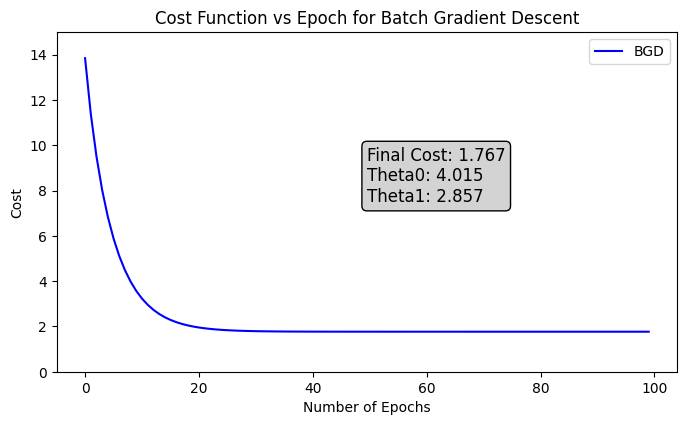

In [ ]:
plt.figure(figsize=(8,15))  # The Canvas is ready

# Plotting for BGD
plt.subplot(3, 1, 1)
plt.plot(range(len(cost_history_bgd)), cost_history_bgd, label = 'BGD', color= 'blue')
plt.title('Cost Function vs Epoch for Batch Gradient Descent')
plt.xlabel('Number of Epochs')
plt.ylabel('Cost')
plt.ylim(0,15)
plt.legend()

plt.annotate(f'Final Cost: {cost_history_bgd[-1]:.3f}\nTheta0: {theta_bgd[0][0]:.3f}\nTheta1: {theta_bgd[1][0]:.3f}',
             xy=(0.5, 0.5), xycoords='axes fraction',
             bbox=dict(boxstyle="round,pad=0.3", edgecolor='black', facecolor='lightgray'), fontsize=12)

plt.show()

### Let us plot the `best fit line` coming out of `BGD`

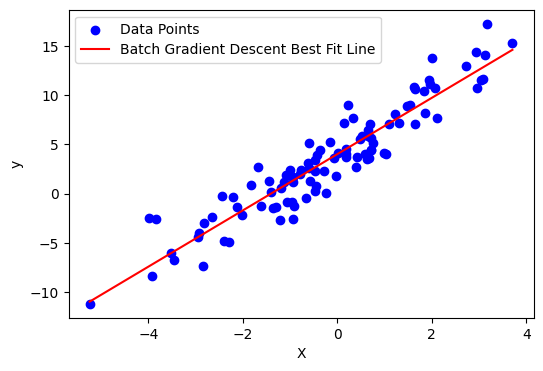

In [ ]:
# Create a range of values for plotting the best fit line
x_plot = np.linspace(X.min(), X.max(),100).reshape(100,1)
x_plot_b = np.c_[np.ones((100,1)), x_plot]

# Plot the best-fit line for BGD on top of the data distribution
plt.figure(figsize = (6,4))
plt.scatter(X,y, color='blue', label='Data Points')
plt.plot(x_plot, x_plot_b.dot(theta_bgd), color = 'red', label = 'Batch Gradient Descent Best Fit Line')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

# Mini-Batch Gradient Descent

### Let's Define `Mini-Batch Gradient Function`

In [ ]:
def mbgd (X, y, theta, learning_rate = 0.1, epochs = 100, batch_size = 32):
  '''
    Mini Batch Gradient Descent using batches of standard size 32
    X = Array of X with the added bias (X_b)
    y = Vector of y
    theta: Array of weight & bias parameters randomly assigned
    learning_rate: Alpha value set to default 0.01
    epochs: Number of times model will run through the entire training dataset
    batch_size = Default batch size is 32 which means that in a mini batch there are 32 samples of the training data by default

    '''

  m = len(y) # Number of Training Rows
  n_batches = int(np.ceil(m/batch_size)) # Integral number of batches from the training dataset
  total_updates = epochs * n_batches # Total Number of updates

  # Arrays to Track cost and theta history
  cost_history = np.zeros(total_updates)                     # 1D array to store cost after each epoch
  theta_history = np.zeros((total_updates, theta.shape[0]))  # 2D array to store parameter values

  iter_num = 0  # To index theta histor and cost history

  for epoch in range(epochs):  # Outer for loop (as many epochs)

    # Shuffle the Training dataset at the begining of each update

    indices = np.random.permutation(m) # Shuffle the indices
    X_shuffled = X[indices]
    y_shuffled = y[indices]

    for i in range(0, m, batch_size):   # Inner for loop (as many batches per epoch)
      X_batch = X_shuffled[i : i + batch_size]
      y_batch = y_shuffled[i : i + batch_size]

      # Calulate the Gradients
      gradients = (X_batch.T.dot(X_batch.dot(theta) - y_batch)) / len(y_batch)  # avg. gradient of a mini-batch one by one
      theta = theta - learning_rate * gradients

      # Record the cost values after each mini-update
      cost = compute_cost(X, y, theta)

      # Update the empty cost and theta arrays after each mini-update
      cost_history[iter_num] = cost  # uni-dimension cost
      theta_history[iter_num, :] = theta.T # 2-D
      iter_num += 1

  return theta, cost_history, theta_history

### Running the `MBGD` Function

In [ ]:
theta

array([[-1.26405266],
       [ 1.52790535]])

In [ ]:
theta_mbgd, cost_history_mbgd, theta_history_mbgd = mbgd(X_b, y, theta, learning_rate=0.1, epochs=100, batch_size=32)

In [ ]:
theta_history_mbgd[:10]

array([[-0.77705109,  1.94530752],
       [-0.31600761,  2.16516658],
       [ 0.14108291,  2.14361824],
       [ 0.45764958,  2.59840674],
       [ 0.75821102,  2.48786423],
       [ 1.12557491,  2.76271503],
       [ 1.43670571,  2.64919072],
       [ 1.55956043,  2.47994234],
       [ 1.79288485,  2.49386281],
       [ 2.02367338,  2.59487036]])

In [ ]:
theta_history_mbgd.shape

(400, 2)

In [ ]:
print('Final MBGD Theta 0 (Bias): {:0.3f}, \nFinal MBGD Theta 1 (Weight): {:0.3f}'.format(theta_mbgd[0][0], theta_mbgd[1][0]))
print('MBGD Final Cost Value: {:0.3f}'.format(cost_history_mbgd[-1]))

Final MBGD Theta 0 (Bias): 4.170, 
Final MBGD Theta 1 (Weight): 2.627
MBGD Final Cost Value: 1.874


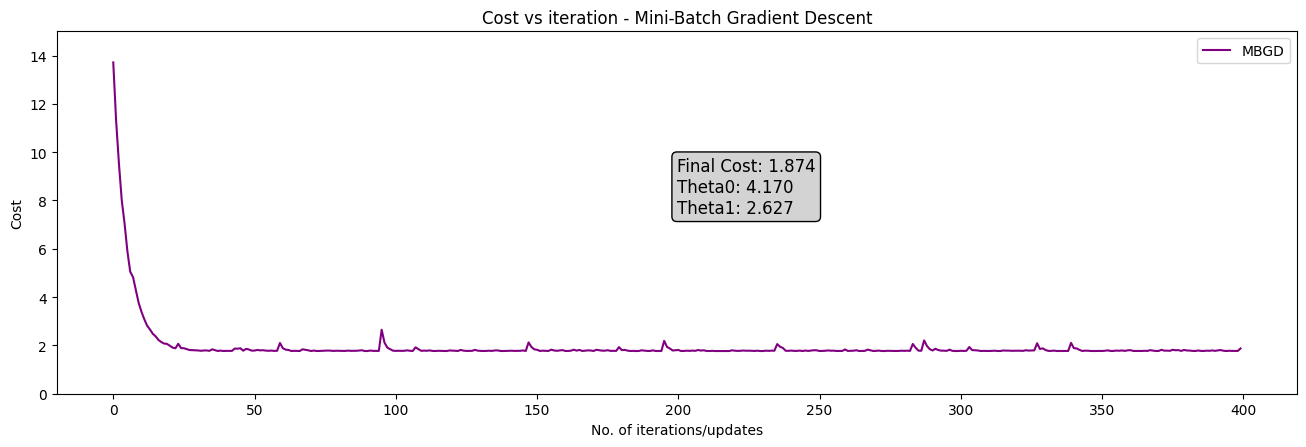

In [ ]:
# Plotting cost history in separate subplots under the same chart
plt.figure(figsize=(16,16)) #canvas ready

# Plot for MBGD
plt.subplot(3,1,1)
plt.plot(range(len(cost_history_mbgd)), cost_history_mbgd, label='MBGD', color='purple')
plt.title('Cost vs iteration - Mini-Batch Gradient Descent')
plt.xlabel('No. of iterations/updates')
plt.ylabel('Cost')
plt.ylim(0,15)
# plt.xlim(100,2000)
plt.legend()
plt.annotate(f'Final Cost: {cost_history_mbgd[-1]:.3f}\nTheta0: {theta_mbgd[0][0]:.3f}\nTheta1: {theta_mbgd[1][0]:.3f}',
             xy=(0.5, 0.5), xycoords='axes fraction',
             bbox=dict(boxstyle="round,pad=0.3", edgecolor='black', facecolor='lightgray'), fontsize=12)
plt.show()

### `MBGD` Best fit line

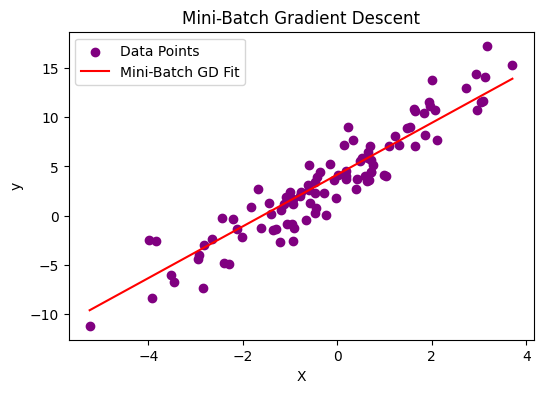

In [ ]:
# Create a range of values for plotting the best fit line
x_plot = np.linspace(X.min(), X.max(), 100).reshape(100, 1)
x_plot_b = np.c_[np.ones((100, 1)), x_plot]

# Plot best-fit lines for each algorithm
plt.figure(figsize=(6, 4))
plt.scatter(X, y, color='purple', label='Data Points')
plt.plot(x_plot, x_plot_b.dot(theta_mbgd), color='red', label='Mini-Batch GD Fit')
plt.title("Mini-Batch Gradient Descent")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

### Creating a combined `best fit line` comparing `BGD` & `MBGD`

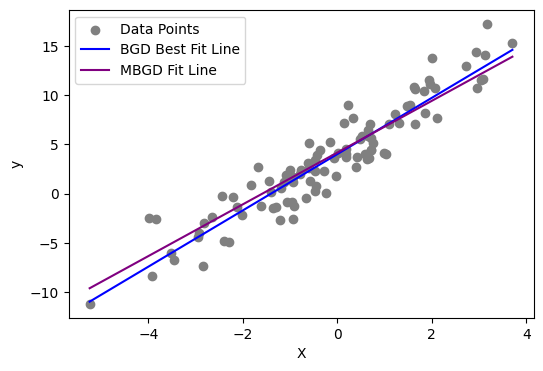

In [ ]:
### Create a range of values for plotting the best fit line
x_plot = np.linspace(X.min(), X.max(),100).reshape(100,1)
x_plot_b = np.c_[np.ones((100,1)), x_plot]

### Plot the best-fit line for BGD on top of the data distribution
plt.figure(figsize = (6,4))
plt.scatter(X,y, color='grey', label='Data Points')
plt.plot(x_plot, x_plot_b.dot(theta_bgd), color = 'blue', label = 'BGD Best Fit Line')
plt.plot(x_plot, x_plot_b.dot(theta_mbgd), color = 'purple', label = 'MBGD Fit Line')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

- Conclusion - Both `MBGD` and `BGD` are almost producing similar best fit lines - looking at the cost function values

# STOCHASTIC GRADIENT DESCENT (SGD)

In [ ]:
def sgd(X, y, theta, learning_rate = 0.1, epochs = 100):

    """
    X = Array of X with the added bias (X_b)
    y = Vector of y
    theta: Array of weight & bias paramter randomly assigned
    learning_rate: alpha value set to default 0.1
    epochs: number of times model will run through the entire training dataset
    """
    m = len(y) # number of training rows

    total_updates = m * epochs # total number of updates = number of training rows * number of epochs

    cost_history = np.zeros(total_updates) #zero-array to store the cost after each update
    theta_history = np.zeros((total_updates, theta.shape[0])) #zero-array to store the parameters (weight & bias) values

    for epoch in range(epochs):

        for i in range(m):

            ### Randomly select a training row/example/record
            rand_index = np.random.randint(0,m)
            X_i = X[rand_index, :].reshape(1, X.shape[1])
            y_i = y[rand_index, :].reshape(1,1)

            ### Compute the gradient for each training row and update the theta values
            gradients = (X_i.T.dot(X_i.dot(theta) - y_i))
            theta = theta - learning_rate * gradients
            cost = compute_cost(X, y, theta)


            ### Update these empty arrays for theta and cost_history
            cost_history[epoch * m + i] = cost # uni-dimension
            theta_history[epoch * m + i, :] = theta.T # 2-dimensions

    return theta, cost_history, theta_history

In [ ]:
theta_sgd, cost_history_sgd, theta_history_sgd = sgd(X_b, y, theta, learning_rate=0.1, epochs=100)

In [ ]:
print('Final SGD Theta 0 (Bias): {:0.3f}, \nFinal SGD Theta 1 (Weight): {:0.3f}'.format(theta_sgd[0][0], theta_sgd[1][0]))
print('SGD Final Cost Value: {:0.3f}'.format(cost_history_sgd[-1]))

Final SGD Theta 0 (Bias): 3.463, 
Final SGD Theta 1 (Weight): 1.815
SGD Final Cost Value: 3.597


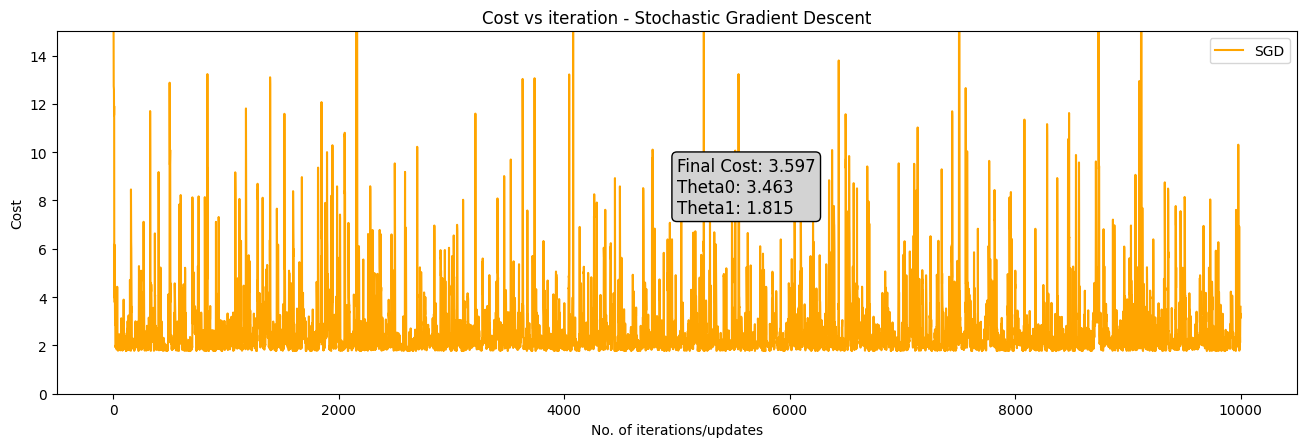

In [ ]:
# Plotting cost history in separate subplots under the same chart
plt.figure(figsize=(16,16)) #canvas ready

# Plot for SGD
plt.subplot(3,1,1)
plt.plot(range(len(cost_history_sgd)), cost_history_sgd, label='SGD', color='orange')
plt.title('Cost vs iteration - Stochastic Gradient Descent')
plt.xlabel('No. of iterations/updates')
plt.ylabel('Cost')
plt.ylim(0,15)
# plt.xlim(100,2000)
plt.legend()
plt.annotate(f'Final Cost: {cost_history_sgd[-1]:.3f}\nTheta0: {theta_sgd[0][0]:.3f}\nTheta1: {theta_sgd[1][0]:.3f}',
             xy=(0.5, 0.5), xycoords='axes fraction',
             bbox=dict(boxstyle="round,pad=0.3", edgecolor='black', facecolor='lightgray'), fontsize=12)
plt.show()

### Best fit line using `SGD`

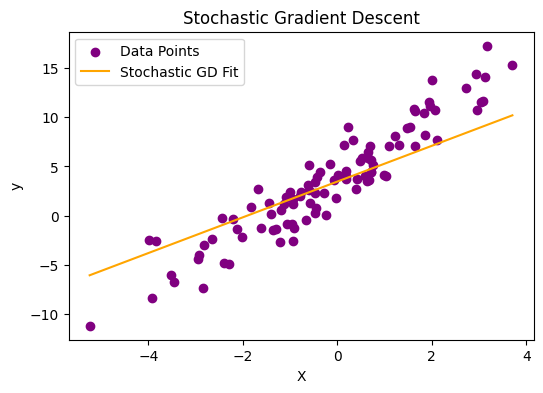

In [ ]:
# Create a range of values for plotting the best fit line
x_plot = np.linspace(X.min(), X.max(), 100).reshape(100, 1)
x_plot_b = np.c_[np.ones((100, 1)), x_plot]

# Plot best-fit lines for each algorithm
plt.figure(figsize=(6, 4))
plt.scatter(X, y, color='purple', label='Data Points')
plt.plot(x_plot, x_plot_b.dot(theta_sgd), color='orange', label='Stochastic GD Fit')
plt.title("Stochastic Gradient Descent")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

### Comparing best fit lines for `BGD`, `MBGD` and `SGD`

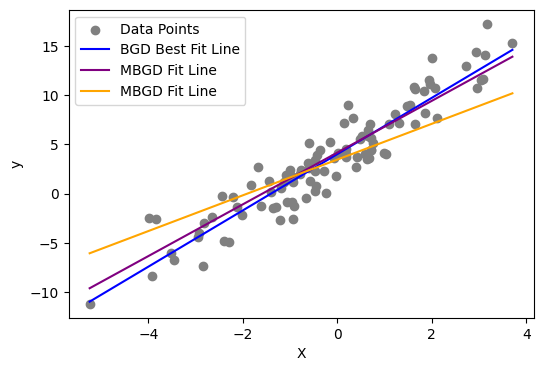

In [ ]:
### Create a range of values for plotting the best fit line
x_plot = np.linspace(X.min(), X.max(),100).reshape(100,1)
x_plot_b = np.c_[np.ones((100,1)), x_plot]

### Plot the best-fit line for BGD on top of the data distribution
plt.figure(figsize = (6,4))
plt.scatter(X,y, color='grey', label='Data Points')
plt.plot(x_plot, x_plot_b.dot(theta_bgd), color = 'blue', label = 'BGD Best Fit Line')
plt.plot(x_plot, x_plot_b.dot(theta_mbgd), color = 'purple', label = 'MBGD Fit Line')
plt.plot(x_plot, x_plot_b.dot(theta_sgd), color = 'orange', label = 'MBGD Fit Line')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()